# BMW Sales Data: Exploratory Data Analysis (EDA)

This notebook contains the exploratory data analysis for the BMW Sales Dataset (2024-2025). The analysis is structured directly around the 10 primary business questions outlined in Section 4 of the project guide. The generated charts are exported to `/images/eda/` for downstream dashboard documentation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)

In [10]:

df = pd.read_csv("../Dataset/clean/bmw_cleaned.csv")

### Q1: Is revenue growing month-over-month across 2024–2025?

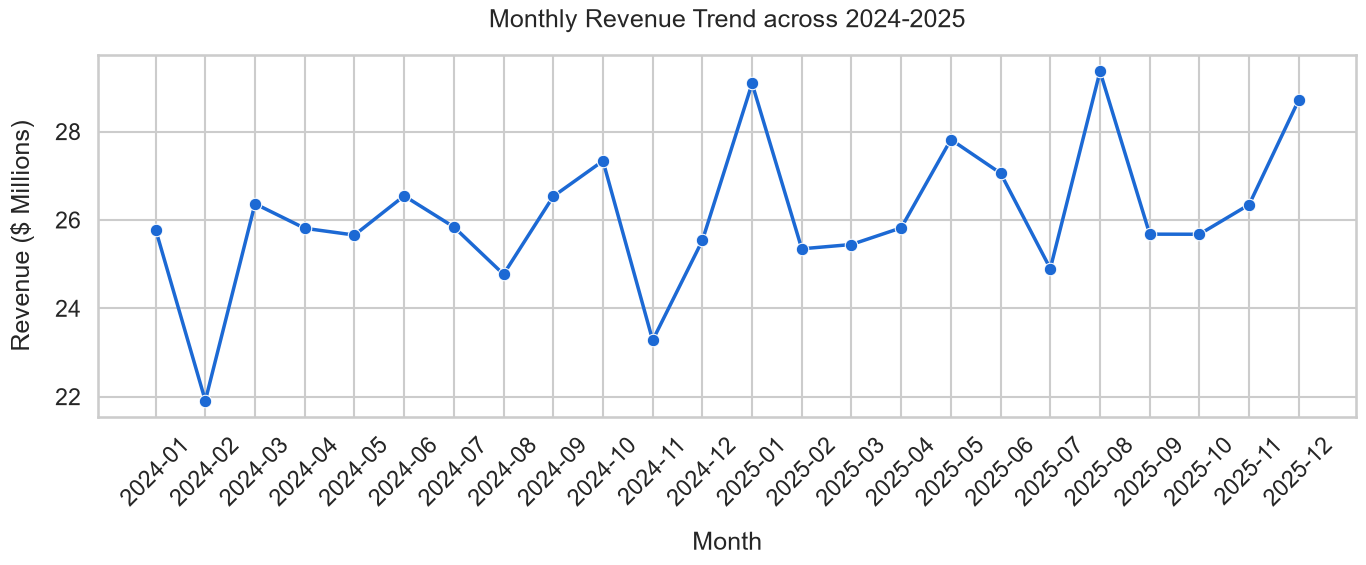

In [11]:
df_q1 = df.copy()
df_q1['sale_date_parsed'] = pd.to_datetime(df_q1['sale_date'])
df_q1['year_month_str'] = df_q1['sale_date_parsed'].dt.to_period('M').astype(str)
monthly_rev = df_q1.groupby('year_month_str')['final_sale_price_usd'].sum() / 1e6

plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, marker='o', color='#1C69D4', linewidth=2.5)
plt.title("Monthly Revenue Trend across 2024-2025", pad=20)
plt.xlabel("Month", labelpad=15)
plt.ylabel("Revenue ($ Millions)", labelpad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** Monthly revenue is relatively stable and slightly fluctuating across 2024-2025, showing an average month-over-month growth rate of 0.92%.

### Q2: Which region contributes the most revenue, and which is growing fastest?

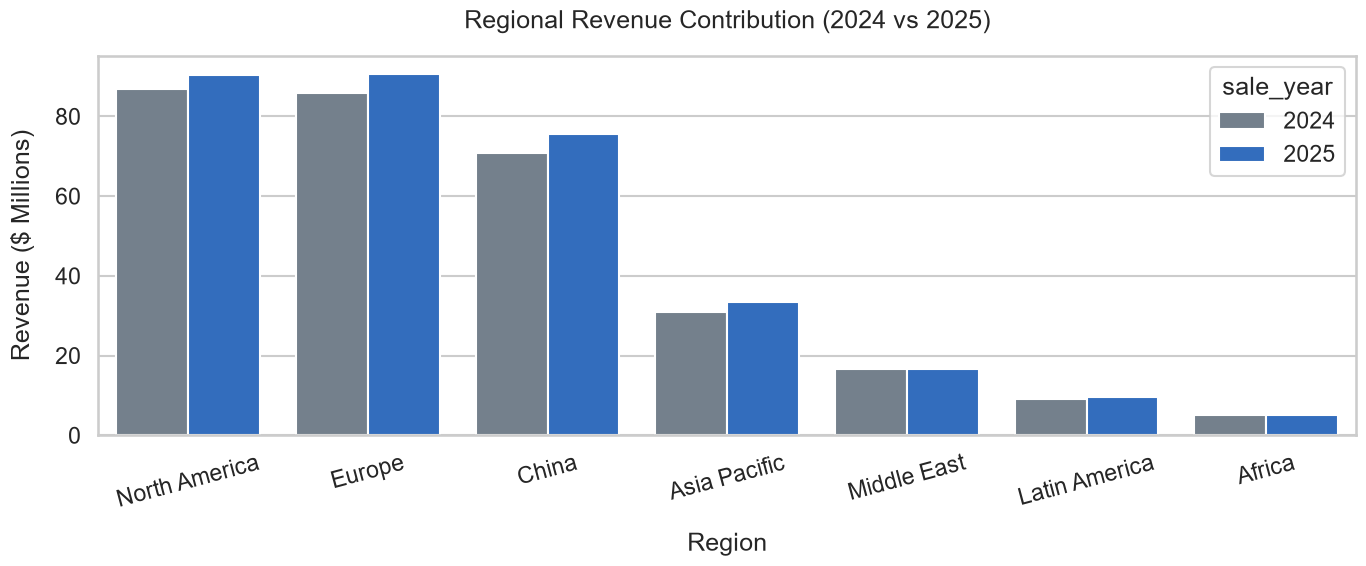

In [12]:
region_order = df.groupby('region')['final_sale_price_usd'].sum().sort_values(ascending=False).index
region_year_rev = df.groupby(['region', 'sale_year'])['final_sale_price_usd'].sum().reset_index()
region_year_rev['final_sale_price_usd'] /= 1e6

plt.figure(figsize=(14, 6))
sns.barplot(data=region_year_rev, x='region', y='final_sale_price_usd', hue='sale_year', order=region_order, palette=['#708090', '#1C69D4'])
plt.title("Regional Revenue Contribution (2024 vs 2025)", pad=20)
plt.xlabel("Region", labelpad=15)
plt.ylabel("Revenue ($ Millions)", labelpad=15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Finding:** North America generates the highest revenue share (28.29%), closely followed by Europe (28.15%), while the Asia Pacific region is growing the fastest with YoY revenue growth of 8.60%.

### Q3: Top models by units sold vs by revenue — do the rankings differ?

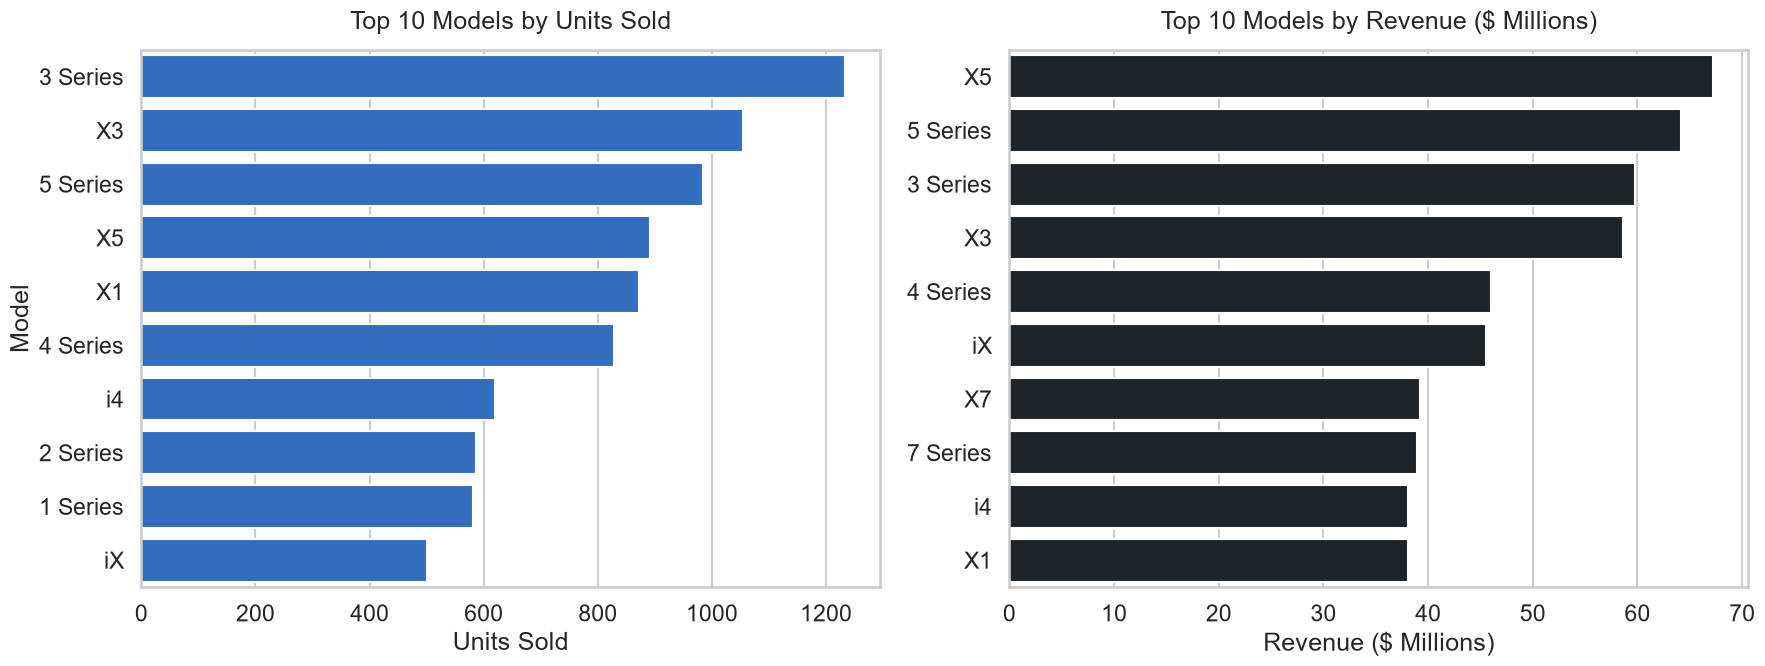

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Units Sold
model_units = df['model'].value_counts().head(10)
sns.barplot(x=model_units.values, y=model_units.index, ax=axes[0], color='#1C69D4')
axes[0].set_title("Top 10 Models by Units Sold", pad=15)
axes[0].set_xlabel("Units Sold")
axes[0].set_ylabel("Model")

# Revenue
model_rev = (df.groupby('model')['final_sale_price_usd'].sum() / 1e6).sort_values(ascending=False).head(10)
sns.barplot(x=model_rev.values, y=model_rev.index, ax=axes[1], color='#1C252C')
axes[1].set_title("Top 10 Models by Revenue ($ Millions)", pad=15)
axes[1].set_xlabel("Revenue ($ Millions)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Finding:** Yes, rankings differ: the 3 Series is the top model by units sold (1,233 units), but the X5 leads in total revenue generation at $67.20 Million.

### Q4: Spread of final_sale_price_usd by segment (boxplot)

C:\Users\josep\AppData\Local\Temp\ipykernel_17692\3027929807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segment', y='final_sale_price_usd', order=segment_order, palette='Blues_r')


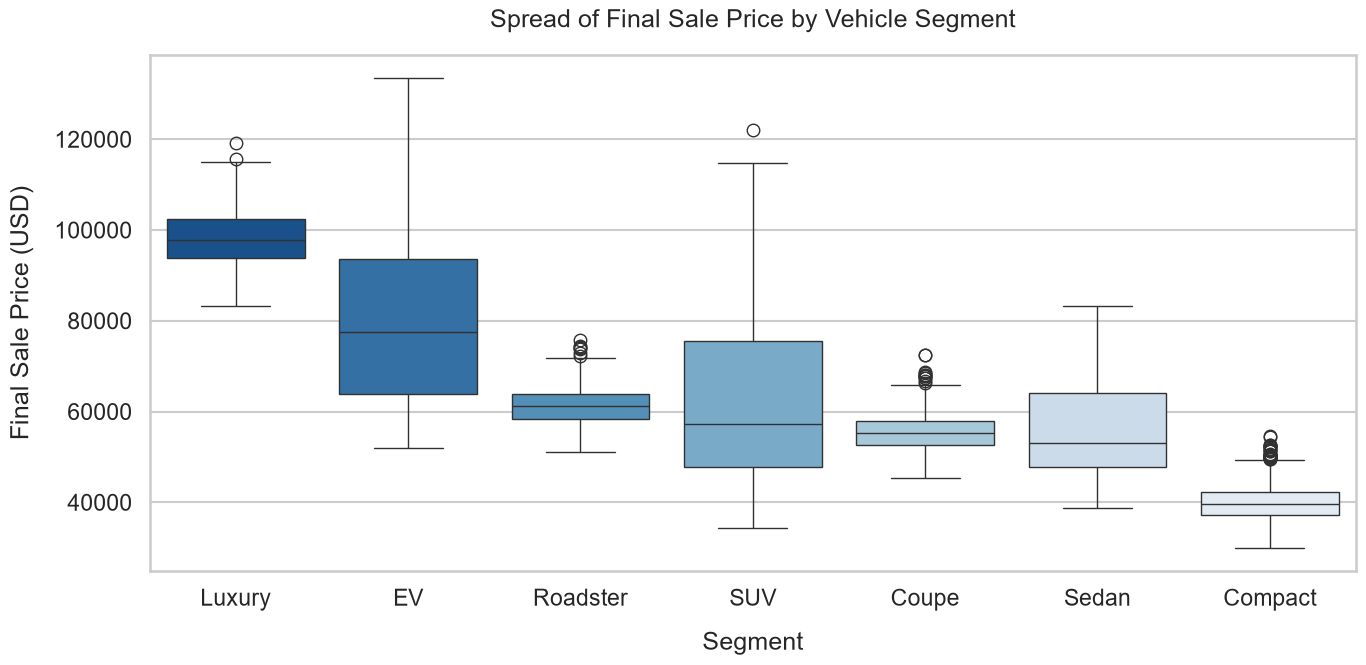

In [14]:
plt.figure(figsize=(14, 7))
segment_order = df.groupby('segment')['final_sale_price_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='segment', y='final_sale_price_usd', order=segment_order, palette='Blues_r')
plt.title("Spread of Final Sale Price by Vehicle Segment", pad=20)
plt.xlabel("Segment", labelpad=15)
plt.ylabel("Final Sale Price (USD)", labelpad=15)
plt.tight_layout()
plt.show()

**Finding:** Luxury has the highest median final sale price ($97,785), which is about 67.4% higher than the overall median price, while Compact represents the lowest end of the pricing spectrum with a median of $39,712.

### Q5: Which models/regions get the deepest average discounts?

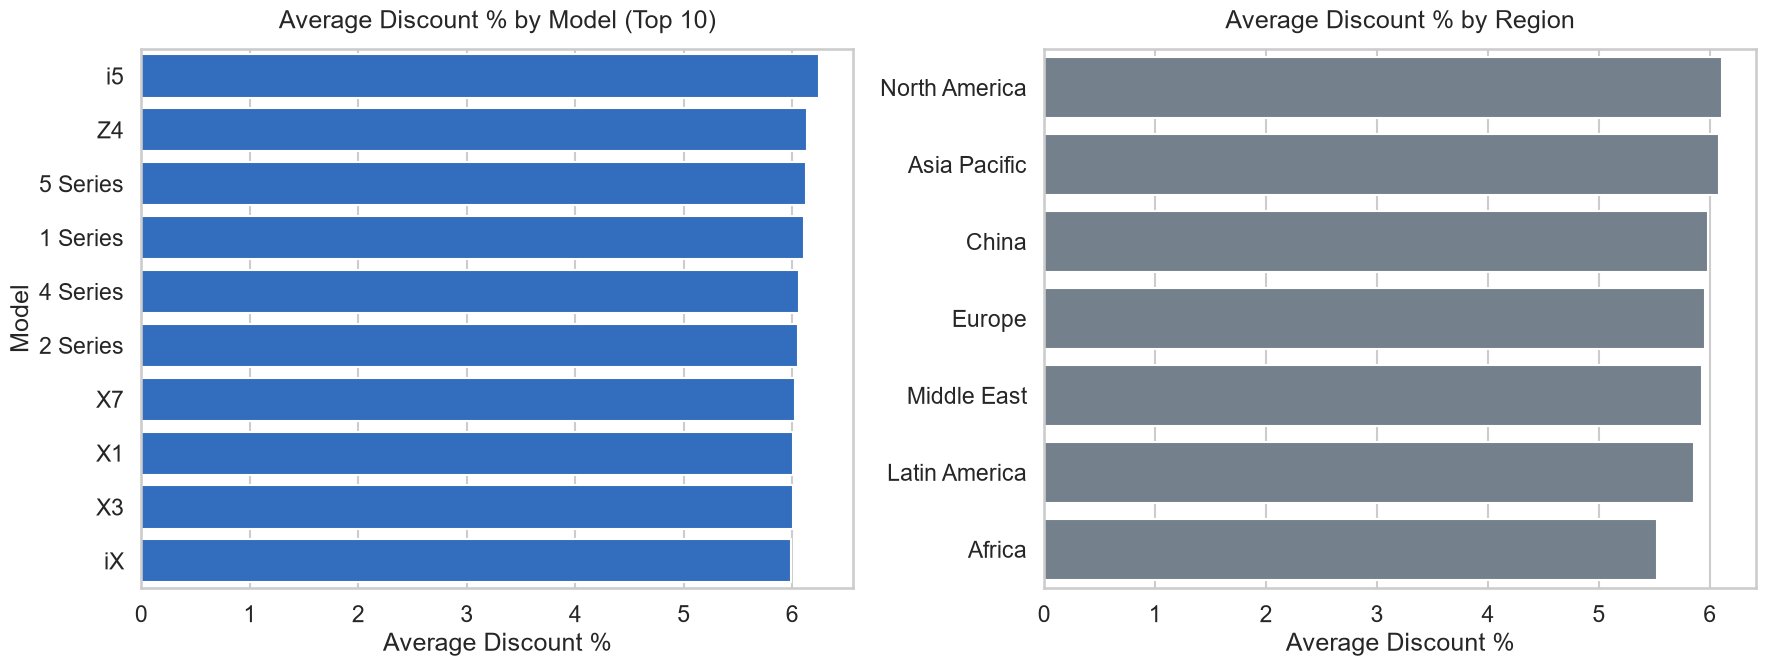

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

avg_disc_model = df.groupby('model')['discount_percent'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_disc_model.values, y=avg_disc_model.index, ax=axes[0], color='#1C69D4')
axes[0].set_title("Average Discount % by Model (Top 10)", pad=15)
axes[0].set_xlabel("Average Discount %")
axes[0].set_ylabel("Model")

avg_disc_region = df.groupby('region')['discount_percent'].mean().sort_values(ascending=False)
sns.barplot(x=avg_disc_region.values, y=avg_disc_region.index, ax=axes[1], color='#708090')
axes[1].set_title("Average Discount % by Region", pad=15)
axes[1].set_xlabel("Average Discount %")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Finding:** The i5 model receives the deepest average discounts at 6.25%, and North America is the region receiving the highest average discounts globally at 6.11%.

### Q6: Does higher discount_bucket correlate with higher or lower customer_satisfaction_score?

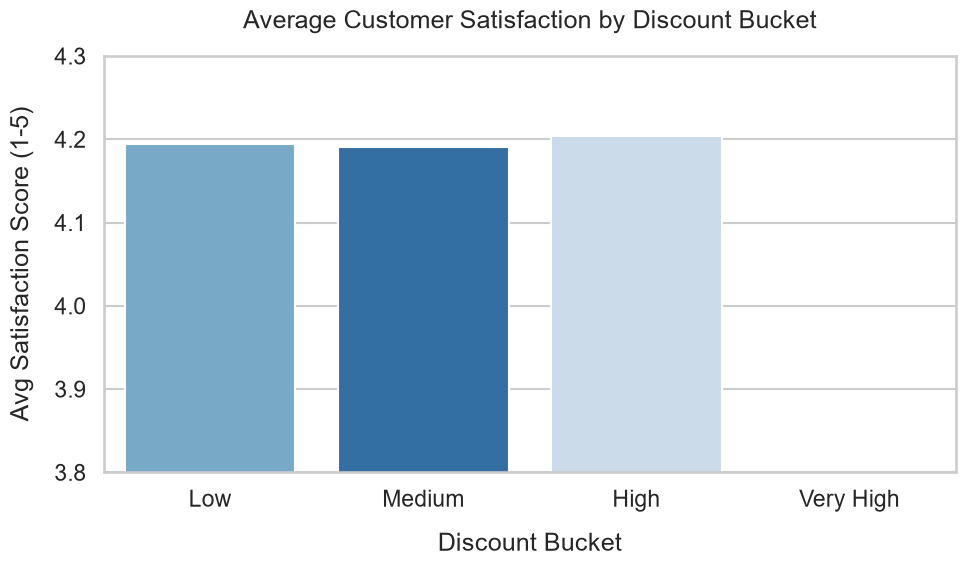

In [22]:
df_sat = df.dropna(subset=['customer_satisfaction_score'])
avg_sat_disc = df_sat.groupby('discount_bucket', observed=False)['customer_satisfaction_score'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_sat_disc, x='discount_bucket', y='customer_satisfaction_score',hue='discount_bucket', palette='Blues', order=['Low', 'Medium', 'High', 'Very High'])
plt.title("Average Customer Satisfaction by Discount Bucket", pad=20)
plt.xlabel("Discount Bucket", labelpad=15)
plt.ylabel("Avg Satisfaction Score (1-5)", labelpad=15)
plt.ylim(3.8, 4.3)
plt.tight_layout()
plt.show()

**Finding:** The High discount bucket has a slightly higher average satisfaction score (4.204) than the Low (4.195) and Medium (4.191) buckets, but the differences are negligible.

### Q7: Is the EV lineup (i4, iX, i5, i7) gaining revenue share vs petrol models across 2024→2025?

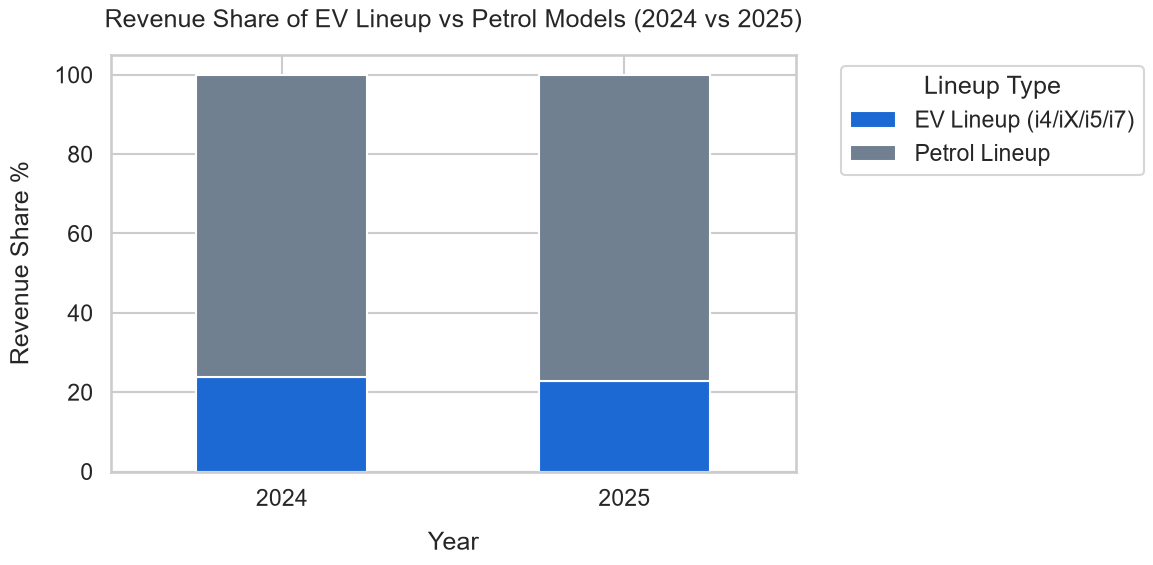

In [23]:
df_ev_petrol = df[df['fuel_type'].isin(['Electric (BEV)', 'Petrol'])].copy()
df_ev_petrol['lineup_type'] = np.where(df_ev_petrol['model'].isin(['i4', 'iX', 'i5', 'i7']), 'EV Lineup (i4/iX/i5/i7)', 'Petrol Lineup')
ev_pet_share = df_ev_petrol.groupby(['sale_year', 'lineup_type'])['final_sale_price_usd'].sum().unstack()
ev_pet_share_pct = ev_pet_share.div(ev_pet_share.sum(axis=1), axis=0) * 100

ev_pet_share_pct.plot(kind='bar', stacked=True, color=['#1C69D4', '#708090'], width=0.5)
plt.title("Revenue Share of EV Lineup vs Petrol Models (2024 vs 2025)", pad=20)
plt.xlabel("Year", labelpad=15)
plt.ylabel("Revenue Share %", labelpad=15)
plt.xticks(rotation=0)
plt.legend(title="Lineup Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Finding:** No, the EV lineup (i4, iX, i5, i7) share of BEV/Petrol revenue decreased slightly from 23.68% in 2024 to 22.67% in 2025.

### Q8: What % of customers are repeat buyers, and does it vary by region?

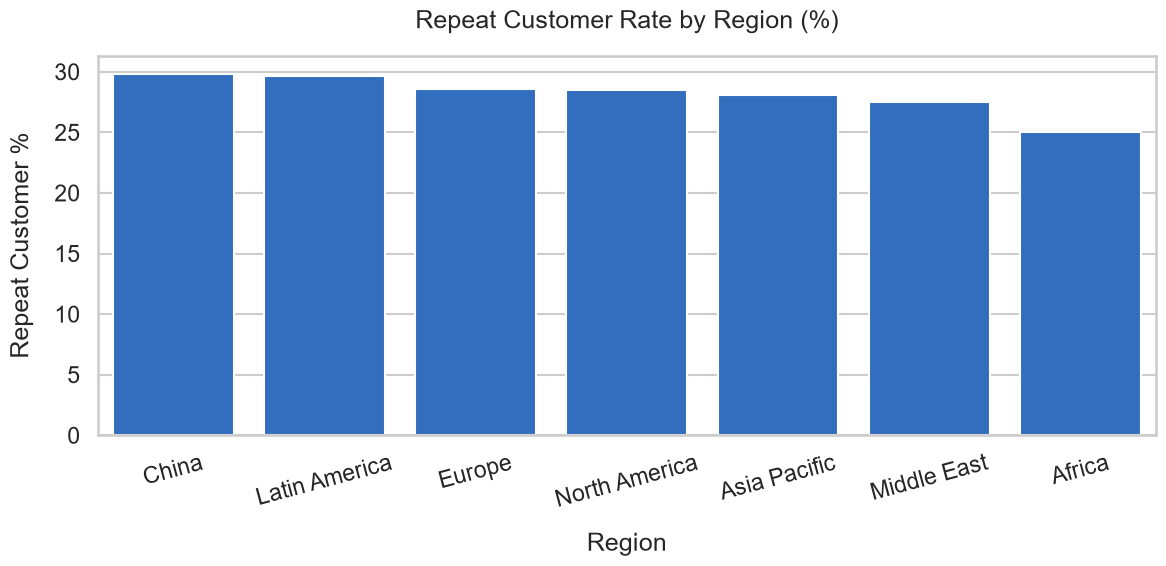

In [18]:
region_repeat = (df.groupby('region')['is_repeat_customer'].mean() * 100).sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=region_repeat, x='region', y='is_repeat_customer', color='#1C69D4')
plt.title("Repeat Customer Rate by Region (%)", pad=20)
plt.xlabel("Region", labelpad=15)
plt.ylabel("Repeat Customer %", labelpad=15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Finding:** Approximately 28.7% of all purchases are by repeat customers globally, with China showing the highest repeat purchase rate (29.81%) and Africa having the lowest (25.00%).

### Q9: Does delivery_category correlate with customer_satisfaction_score?

C:\Users\josep\AppData\Local\Temp\ipykernel_17692\3776896242.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_del_sat, x='delivery_category', y='customer_satisfaction_score', palette='Blues', order=['Fast', 'Normal', 'Delayed'])


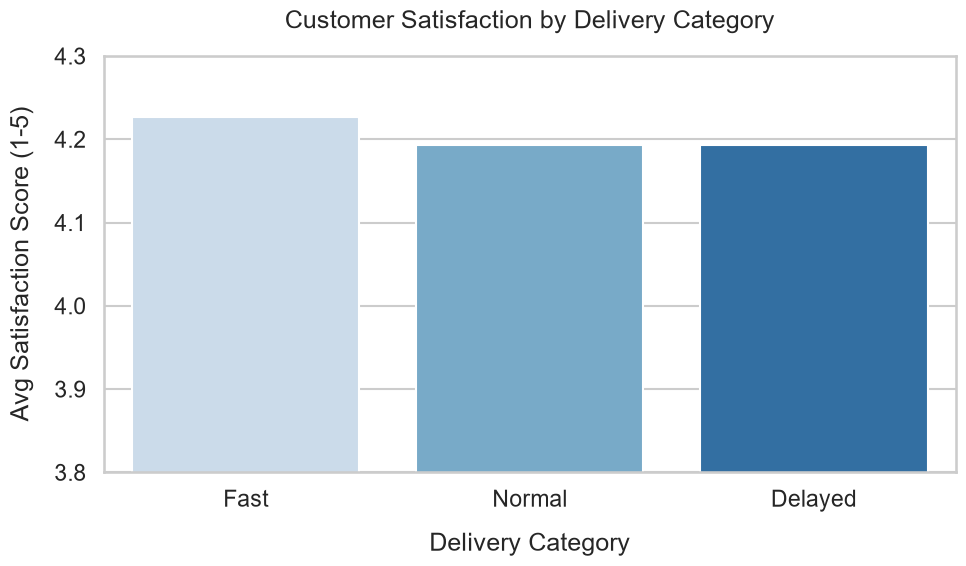

In [19]:
df_del_sat = df.dropna(subset=['customer_satisfaction_score'])
avg_del_sat = df_del_sat.groupby('delivery_category')['customer_satisfaction_score'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_del_sat, x='delivery_category', y='customer_satisfaction_score', palette='Blues', order=['Fast', 'Normal', 'Delayed'])
plt.title("Customer Satisfaction by Delivery Category", pad=20)
plt.xlabel("Delivery Category", labelpad=15)
plt.ylabel("Avg Satisfaction Score (1-5)", labelpad=15)
plt.ylim(3.8, 4.3)
plt.tight_layout()
plt.show()

**Finding:** Customers experiencing Fast delivery (<7 days) report a slightly higher average satisfaction score (4.227) compared to those with Normal (4.194) and Delayed (4.193) delivery categories.

### Q10: Correlation heatmap across numeric columns (price, discount, satisfaction, delivery, options cost)

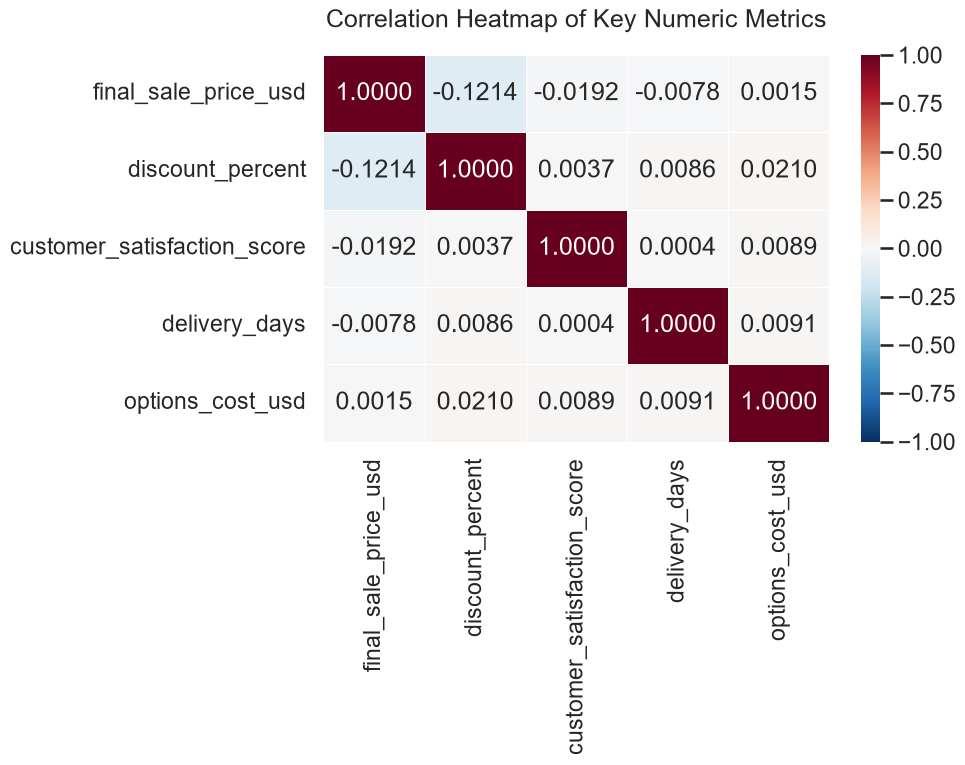

In [20]:
plt.figure(figsize=(10, 8))
numeric_cols = ['final_sale_price_usd', 'discount_percent', 'customer_satisfaction_score', 'delivery_days', 'options_cost_usd']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".4f", linewidths=0.5)
plt.title("Correlation Heatmap of Key Numeric Metrics", pad=20)
plt.tight_layout()
plt.show()

**Finding:** No correlation pairs among the numeric variables exceed the 0.4 threshold. The highest absolute linear correlation exists between final sale price and discount percent at -0.1214.